In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import sys
sys.path.append("../src")
from preprocessing import preprocessor

In [3]:
df = pd.read_csv("../Dataset/dataset.csv")

In [4]:
df["Security_Type"] = df["Security_Type"].replace("Indriect", "Indirect")

In [5]:
df["ID"].nunique()

148670

In [6]:
df["Status"].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

In [7]:
df["year"].nunique()

1

In [8]:
df.groupby("Security_Type")["Status"].mean()

Security_Type
Indirect    1.000000
direct      0.246278
Name: Status, dtype: float64

In [9]:
pd.crosstab(df["Interest_rate_spread"].isna(), df["Status"])

Status,0,1
Interest_rate_spread,,
False,112031,0
True,0,36639


In [10]:
pd.crosstab(df["Upfront_charges"].isna(), df["Status"])

Status,0,1
Upfront_charges,,
False,108875,153
True,3156,36486


In [11]:
pd.crosstab(df["rate_of_interest"].isna(), df["Status"])

Status,0,1
rate_of_interest,,
False,112031,200
True,0,36439


In [12]:
df.groupby("credit_type")["Status"].mean()

credit_type
CIB     0.158041
CRIF    0.162343
EQUI    0.999935
EXP     0.159854
Name: Status, dtype: float64

In [13]:
pd.crosstab(df["construction_type"], df["Status"])

Status,0,1
construction_type,,
mh,0,33
sb,112031,36606


In [14]:
pd.crosstab(df["Secured_by"], df["Status"])

Status,0,1
Secured_by,,
home,112031,36606
land,0,33


In [15]:
X = df.drop(columns=[
    "ID",
    "year",
    "Status",
    "Security_Type",
    "Interest_rate_spread",
    "Upfront_charges",
    "rate_of_interest",
    "construction_type",
    "Secured_by",
    "credit_type"
])
y = df["Status"]
print(X.shape)
print(y.shape)

(148670, 24)
(148670,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (118936, 24)
Testing data: (29734, 24)


## Logistic Regression

In [17]:
logistic_model = Pipeline([("preprocessor", preprocessor),
                           ("model", LogisticRegression(C=1,solver="liblinear",max_iter=1000, class_weight="balanced"))])

In [18]:
logistic_model.fit(X_train, y_train)
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [19]:
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [20]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC-AUC  :", lr_auc)

Accuracy : 0.7056231923051053
Precision: 0.43443452654826537
Recall   : 0.6442412663755459
F1 Score : 0.5189337730145644
ROC-AUC  : 0.7468668716699791


In [21]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.73      0.79     22406
           1       0.43      0.64      0.52      7328

    accuracy                           0.71     29734
   macro avg       0.65      0.68      0.65     29734
weighted avg       0.76      0.71      0.72     29734



In [22]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

[[16260  6146]
 [ 2607  4721]]


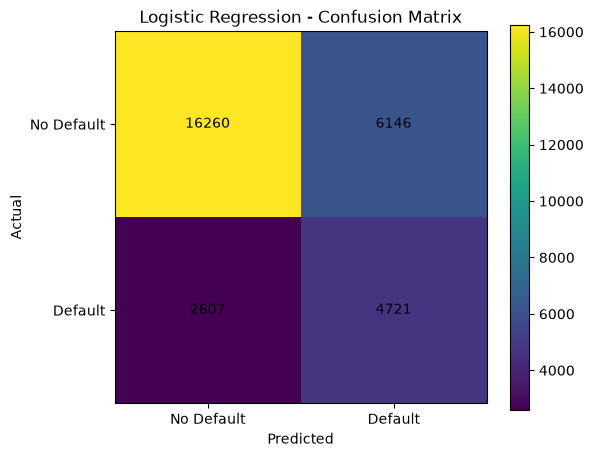

In [23]:
plt.figure(figsize=(6, 5))
plt.imshow(cm_lr)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["No Default", "Default"])
plt.yticks([0, 1], ["No Default", "Default"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_lr[i, j], ha="center", va="center")
plt.colorbar()
plt.show()

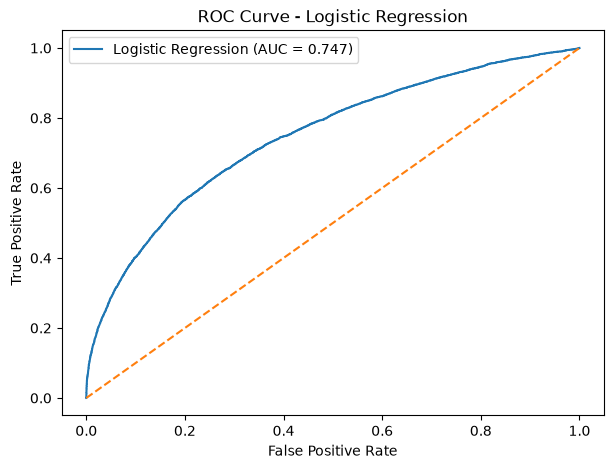

In [24]:
lr_auc = roc_auc_score(y_test, y_prob_lr)
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {lr_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

## Desicion Tree

In [28]:
decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(criterion="gini", max_depth=3,random_state=42, class_weight="balanced"))])
decision_tree_model.fit(X_train, y_train)
print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [29]:
tree_model = decision_tree_model.named_steps["model"]
print("Gini values of nodes:")
print(tree_model.tree_.impurity)

Gini values of nodes:
[0.5        0.47413745 0.49019405 0.47762801 0.45207789 0.06402157
 0.02860601 0.46446674 0.42577793 0.39345429 0.33690086 0.38128663
 0.3795958  0.4967306  0.17922355]


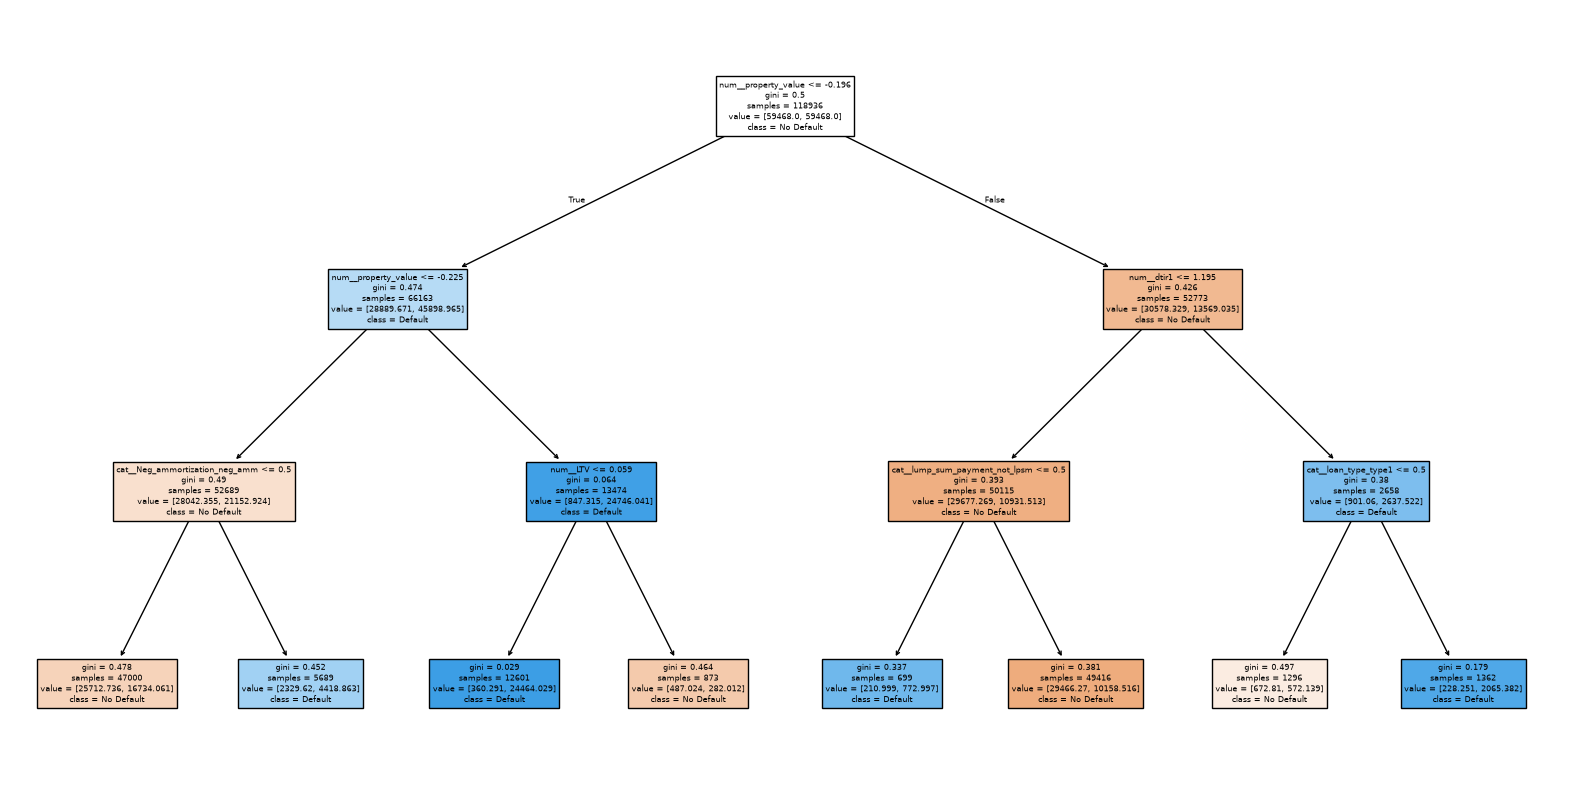

In [30]:
plt.figure(figsize=(20, 10))
tree.plot_tree(
    tree_model,
    filled=True,
    feature_names=decision_tree_model.named_steps["preprocessor"].get_feature_names_out(),
    class_names=["No Default", "Default"],
    max_depth=3
)
plt.show()

In [25]:
y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

In [26]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_prob_dt)
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC-AUC  :", dt_auc)

Accuracy : 0.8485235757045806
Precision: 0.8400770712909441
Recall   : 0.4759825327510917
F1 Score : 0.6076655052264809
ROC-AUC  : 0.7684420394646319


In [27]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.85      0.97      0.91     22406
           1       0.84      0.48      0.61      7328

    accuracy                           0.85     29734
   macro avg       0.84      0.72      0.76     29734
weighted avg       0.85      0.85      0.83     29734



In [28]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

[[21742   664]
 [ 3840  3488]]


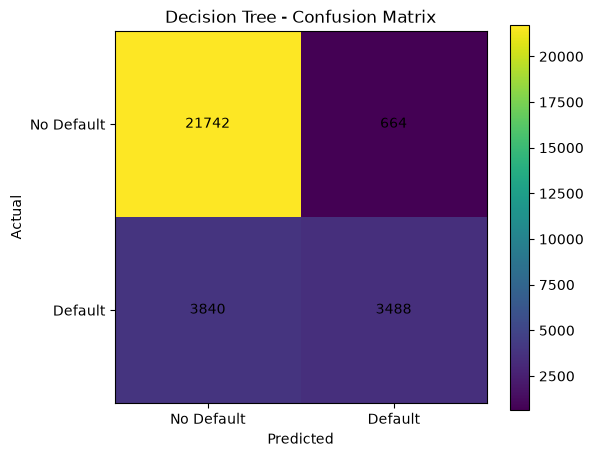

In [29]:
plt.figure(figsize=(6, 5))
plt.imshow(cm_dt)
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["No Default", "Default"])
plt.yticks([0, 1], ["No Default", "Default"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_dt[i, j],ha="center", va="center")
plt.colorbar()
plt.show()

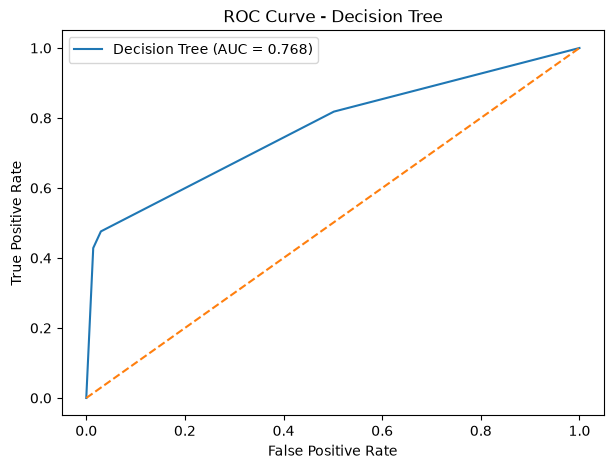

In [30]:
fpr_dt, tpr_dt, thresholds_dt = roc_curve( y_test, y_prob_dt)
plt.figure(figsize=(7, 5))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {dt_auc:.3f})")
plt.plot([0, 1],[0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

In [31]:
feature_names = decision_tree_model.named_steps["preprocessor"].get_feature_names_out()
importance = pd.Series(tree_model.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Top 15 Important Features:")
print(importance.head(15))

Top 15 Important Features:
num__property_value                  0.909961
num__dtir1                           0.090039
num__loan_amount                     0.000000
cat__co-applicant_credit_type_EXP    0.000000
cat__interest_only_not_int           0.000000
cat__lump_sum_payment_lpsm           0.000000
cat__lump_sum_payment_not_lpsm       0.000000
cat__occupancy_type_ir               0.000000
cat__occupancy_type_pr               0.000000
cat__occupancy_type_sr               0.000000
cat__total_units_1U                  0.000000
cat__total_units_2U                  0.000000
cat__total_units_3U                  0.000000
cat__total_units_4U                  0.000000
cat__co-applicant_credit_type_CIB    0.000000
dtype: float64


In [32]:
print("Tree Depth:", tree_model.get_depth())
print("Number of Leaves:", tree_model.get_n_leaves())

Tree Depth: 2
Number of Leaves: 4


In [33]:
for col in X.columns:
    if X[col].nunique() <= 10:
        values = df.groupby(col)["Status"].nunique()
        if values.max() == 1:
            print("Possible leakage:", col)

### Hyperparameter Tuning

In [34]:
lr_params = {"model__C": [0.1, 1, 10], "model__solver": ["liblinear"]}
lr_grid = GridSearchCV(logistic_model, lr_params, cv=3, scoring="f1", n_jobs=-1)
lr_grid.fit(X_train, y_train)
print("Best Parameters:", lr_grid.best_params_)
print("Best CV F1 Score:", lr_grid.best_score_)

Best Parameters: {'model__C': 1, 'model__solver': 'liblinear'}
Best CV F1 Score: 0.5169973481616198


In [35]:
dt_params = {"model__max_depth": [3, 5, 7, 10], "model__min_samples_split": [2, 5, 10]}
dt_grid = GridSearchCV(decision_tree_model, dt_params, cv=3, scoring="f1", n_jobs=-1)
dt_grid.fit(X_train, y_train)
print("Best Parameters:", dt_grid.best_params_)
print("Best CV F1 Score:", dt_grid.best_score_)

Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 10}
Best CV F1 Score: 0.7009445464635989


In [36]:
best_lr = lr_grid.best_estimator_
best_dt = dt_grid.best_estimator_
print("Best Logistic Regression model:", best_lr)
print()
print("Best Decision Tree model:", best_dt)

Best Logistic Regression model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amount', 'term',
                                                   'property_value', 'income',
                                                   'Credit_Score', 'LTV',
                                                   'dtir1']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),


In [37]:
best_lr = lr_grid.best_estimator_
best_dt = dt_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]
y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]

In [38]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

Logistic Regression
Accuracy: 0.7056231923051053
Precision: 0.43443452654826537
Recall: 0.6442412663755459
F1: 0.5189337730145644
ROC-AUC: 0.7468668716699791

Decision Tree
Accuracy: 0.8576713526602543
Precision: 0.7211428571428572
Recall: 0.6888646288209607
F1: 0.7046342825237297
ROC-AUC: 0.8647421096364939


In [39]:
tree_model = best_dt.named_steps["model"]
feature_names = best_dt.named_steps["preprocessor"].get_feature_names_out()
importance = pd.Series(tree_model.feature_importances_, index=feature_names).sort_values(ascending=False)
print(importance.head(15))

num__property_value                       0.542998
num__dtir1                                0.094492
num__LTV                                  0.090024
cat__Neg_ammortization_neg_amm            0.048904
num__income                               0.048709
cat__lump_sum_payment_lpsm                0.026562
cat__loan_type_type1                      0.026492
cat__lump_sum_payment_not_lpsm            0.020482
cat__submission_of_application_to_inst    0.016752
cat__Credit_Worthiness_l1                 0.012527
num__loan_amount                          0.011934
cat__loan_limit_ncf                       0.010385
cat__business_or_commercial_b/c           0.008205
cat__loan_purpose_p3                      0.007387
cat__approv_in_adv_nopre                  0.006458
dtype: float64


In [38]:
print(df.groupby("Status")["Upfront_charges"].describe())

           count         mean          std  min     25%      50%       75%  \
Status                                                                       
0       108875.0  3227.328554  3251.673989  0.0  584.39  2600.00  4815.315   
1          153.0  1565.237974  2299.820513  0.0    0.00   687.85  2310.750   

            max  
Status           
0       60000.0  
1       15584.0  


In [39]:
print(df["Upfront_charges"].isna().groupby(df["Status"]).value_counts())

Status  Upfront_charges
0       False              108875
        True                 3156
1       True                36486
        False                 153
Name: count, dtype: int64


In [41]:
importance = best_dt.named_steps["model"].feature_importances_
features = best_dt.named_steps["preprocessor"].get_feature_names_out()
feature_importance = pd.DataFrame({ "Feature": features, "Importance": importance})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
print(feature_importance.head(15))

                                   Feature  Importance
2                      num__property_value    0.542998
6                               num__dtir1    0.094492
5                                 num__LTV    0.090024
28          cat__Neg_ammortization_neg_amm    0.048904
3                              num__income    0.048709
32              cat__lump_sum_payment_lpsm    0.026562
15                    cat__loan_type_type1    0.026492
33          cat__lump_sum_payment_not_lpsm    0.020482
51  cat__submission_of_application_to_inst    0.016752
22               cat__Credit_Worthiness_l1    0.012527
0                         num__loan_amount    0.011934
8                      cat__loan_limit_ncf    0.010385
26         cat__business_or_commercial_b/c    0.008205
20                    cat__loan_purpose_p3    0.007387
13                cat__approv_in_adv_nopre    0.006458


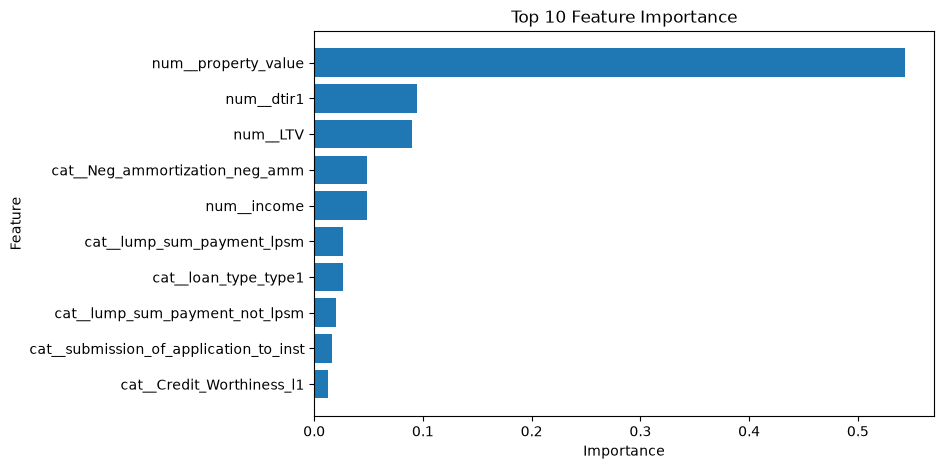

In [42]:
top_features = feature_importance.head(10)
plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [43]:
logistic_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['loan_limit','Gender','approv_in_adv',...,'LTV','Region','dtir1']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

In [44]:
import joblib

joblib.dump(best_dt, "../models/best_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.
